In [1]:
import numpy as np
def cosine_similarity(a,b):
  return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
good=np.array([0.82,0.41,0.10])
great=np.array([0.79,0.38,0.12])
bad=np.array([-0.71,0.12,-0.05])
print(f'good and great:{cosine_similarity(good,great):.3f}')
print(f'good and bad : {cosine_similarity(good,bad):.3f}')
print(f'great and bad:{cosine_similarity(great,bad):.3f}')

good and great:1.000
good and bad : -0.808
great and bad:-0.816


In [2]:
!pip install gensim
from gensim.models import Word2Vec
sentences = [
'the king ruled the kingdom wisely',
'the queen ruled the land gracefully',
'the prince will become king one day',
'a man walked into the palace',
'a woman walked into the palace',
'the dog barked loudly in the garden',
'the puppy played happily in the garden',
]
tokenised = [s.split() for s in sentences]
model = Word2Vec(sentences=tokenised, vector_size=50,
window=3, min_count=1, sg=1, epochs=200)
print(model.wv.most_similar('king', topn=3))
result = model.wv.most_similar(
positive=['king', 'woman'],
negative=['man'],
topn=2
)
print('king - man + woman =', result[1][0])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.2 MB/s eta 0:00:00
[('kingdom', 0.40141454339027405), ('played', 0.38476690649986267), ('in', 0.38395753502845764)]
king - man + woman = land


In [3]:
import sys
!{sys.executable} -m pip install gensim
# Step 0: Download GloVe vectors
# https://nlp.stanford.edu/data/glove.6B.zip (about 800 MB)
# Extract and you get: glove.6B.50d.txt, glove.6B.100d.txt, etc.
!wget --no-check-certificate https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# Step 1: Convert GloVe format to Word2Vec format (one-time step)
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')
# Step 2: Load the converted file
from gensim.models import KeyedVectors
glove = KeyedVectors.load_word2vec_format(
'glove.6B.100d.w2v.txt', binary=False
) # Takes ~30 seconds; 400,000 words x 100 dimensions
# Step 3: Use it!
# --- Find top-5 most similar words ---
print(glove.most_similar('bollywood', topn=5))
# [('cinema', 0.82), ('films', 0.79), ('actors', 0.77), ...]
# --- Test analogy ---
res = glove.most_similar(positive=['paris','tamilnadu'], negative=['france'],
topn=1)
print('paris - france + india =', res[0][0]) # hopefully 'delhi'!
# --- Cosine similarity between two words ---
print(glove.similarity('dog', 'puppy')) # ~0.81
print(glove.similarity('cat', 'cricket')) # ~0.12 (unrelated)


--2026-06-11 07:54:41--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-11 07:54:42--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.28MB/s    in 2m 44s  

2026-06-11 07:57:26 (5.02 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



/tmp/ipykernel_6802/3113185206.py:11: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


[('malayalam', 0.6783681511878967), ('film', 0.660624086856842), ('films', 0.6603192090988159), ('hindi', 0.6582645773887634), ('movie', 0.6446917653083801)]
paris - france + india = bhubaneswar
0.7236376
0.1919626


In [4]:
import gensim.downloader as api
glove_sm=api.load('glove-wiki-gigaword-100')
print(glove_sm.most_similar('bollywood',topn=5))

[==================================================] 100.0% 128.1/128.1MB downloaded
[('malayalam', 0.6783681511878967), ('film', 0.660624086856842), ('films', 0.6603192090988159), ('hindi', 0.6582645773887634), ('movie', 0.6446917653083801)]


Missing words: {'kitten', 'france', 'england', 'samparis', 'delhi', 'puppy', 'man', 'dog', 'queen', 'king', 'prince', 'india', 'princess', 'london', 'woman', 'cat'}
Vector matrix shape: (15, 100)


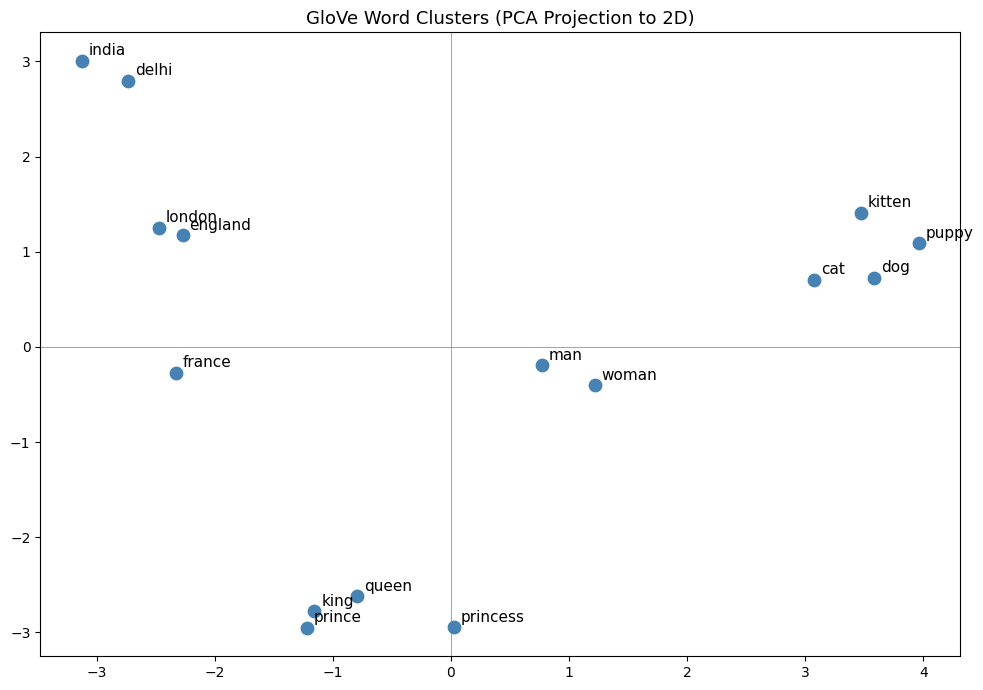

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

# Assuming you already loaded GloVe:
# glove = KeyedVectors.load_word2vec_format(
#     'glove.6B.100d.w2v.txt',
#     binary=False
# )

# Words to visualize
words = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'dog', 'puppy', 'cat', 'kitten','rama chandra','sam'
    'paris', 'france', 'delhi', 'india', 'london', 'england'
]

# Keep only words that exist in the model
valid_words = [w for w in words if w in glove.key_to_index]

missing_words = set(words) - set(missing_words)
if missing_words:
    print("Missing words:", missing_words)

# Extract vectors
vectors = np.array([glove[w] for w in valid_words])

print("Vector matrix shape:", vectors.shape)

# Reduce dimensions from 100D -> 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=80,
    color='steelblue',
    zorder=3
)

# Add labels
for i, word in enumerate(valid_words):
    ax.annotate(
        word,
        (coords[i, 0], coords[i, 1]),
        fontsize=11,
        xytext=(5, 4),
        textcoords='offset points'
    )

ax.set_title(
    'GloVe Word Clusters (PCA Projection to 2D)',
    fontsize=13
)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('word_clusters.png', dpi=150)
plt.show()


In [9]:
import numpy as np

def sentence_vector(sentence, model, dim=100):
    '''
    Convert a sentence to a single vector by averaging its word vectors.
    Words not in the vocabulary are silently skipped.
    '''
    tokens = sentence.lower().split()  # tokenise

    vectors = []

    for token in tokens:
        if token in model:  # only use words we have vectors for
            vectors.append(model[token])  # model[token] returns a 100-D array

    if not vectors:  # if ALL words are unknown
        return np.zeros(dim)  # return a zero vector as fallback

    return np.mean(vectors, axis=0)  # element-wise average across all words


# Test it
s1 = 'man bite the dog at morning'
s2 = 'dog bite the man at afternoon'
s3 = 'A romantic comedy about falling in love in Paris'

v1 = sentence_vector(s1, glove)
v2 = sentence_vector(s2, glove)
v3 = sentence_vector(s3, glove)

# Compare similarity
from numpy.linalg import norm

cos = lambda a, b: np.dot(a, b) / (norm(a) * norm(b))  # cosine similarity

print(f's1 vs s2 (both action): {cos(v1, v2):.3f}')  # high ~0.93
print(f's1 vs s3 (action vs romance): {cos(v1, v3):.3f}')  # lower ~0.61

# The model correctly identifies that s1 and s2 are more similar!

s1 vs s2 (both action): 0.998
s1 vs s3 (action vs romance): 0.823


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
# df has columns: 'description' (text) and 'genre' (label)

df = pd.DataFrame({
    "description": [
        "A brave warrior saves humanity from destruction",
        "A hero fights evil forces to protect the world",
        "Two strangers fall in love in Paris",
        "A romantic story about relationships and emotions",
        "A hilarious comedy full of funny situations",
        "Friends experience a series of humorous adventures",
        "A detective investigates a mysterious murder case",
        "A criminal conspiracy shocks the entire city"
    ],
    "genre": [
        "action",
        "action",
        "romance",
        "romance",
        "comedy",
        "comedy",
        "crime",
        "crime"
    ]
})
# Build one 100-D vector per movie description
# This replaces TF-IDF — instead of word counts, we use semantic meaning
X = np.array([sentence_vector(desc, glove) for desc in df['description']])
y = df['genre'] # e.g. 'action', 'romance', 'comedy'
# Standard train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.5, random_state=42, stratify=y
)
# Logistic Regression on semantic vectors
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_tr, y_tr)
print(classification_report(y_te, clf.predict(X_te)))
# Embedding-based model beats TF-IDF on unseen vocabulary!


              precision    recall  f1-score   support

      action       1.00      1.00      1.00         1
      comedy       1.00      1.00      1.00         1
       crime       1.00      1.00      1.00         1
     romance       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

